# SaaS Product Analytics & Churn Prediction

## 04 — Retention & Cohort Analysis

### Objective

Analyze customer retention and cohort behavior across the SaaS product.

Retention analysis helps answer whether customers continue using the product after their initial adoption.

This notebook analyzes:

- Customer cohorts
- Monthly retention
- Cohort retention rates
- User retention curves
- New versus returning users
- Customer activity persistence
- Retention differences across plans
- Early indicators of customer churn

### Business Importance

Acquiring customers is only one part of SaaS growth.

A sustainable SaaS business must also retain customers and maintain product engagement over time.

The analysis therefore focuses on:

> Do customers continue using the SaaS product after their first activity?

The questions analyzed here are part of the broader business-question framework documented in `business_questions.md`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

print("Libraries imported successfully.")

Libraries imported successfully.


## 1. Project Configuration

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name.lower() == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
ANALYTICS_DIR = PROJECT_ROOT / "data" / "analytics"

print("Project root:")
print(PROJECT_ROOT)

Project root:
c:\Users\user\Desktop\Data Analysis Projects\SaaS Product Analytics & Churn Prediction


## 2. Load Required Datasets

Retention analysis primarily requires:

- Users
- Events

Subscriptions will be used later to compare retention across customer plans and subscription groups.

In [3]:
def load_dataset(filename):
    processed_path = PROCESSED_DATA_DIR / filename
    raw_path = RAW_DATA_DIR / filename

    if processed_path.exists():
        return pd.read_csv(processed_path)

    if raw_path.exists():
        return pd.read_csv(raw_path)

    raise FileNotFoundError(
        f"Could not find {filename}."
    )


users = load_dataset("users.csv")
events = load_dataset("events.csv")
subscriptions = load_dataset("subscriptions.csv")

print(f"Users loaded: {len(users):,}")
print(f"Events loaded: {len(events):,}")
print(f"Subscriptions loaded: {len(subscriptions):,}")

Users loaded: 30,000
Events loaded: 1,552,178
Subscriptions loaded: 30,000


## 3. Prepare Event Dates

Retention analysis requires a consistent date field.

We convert the event timestamp into:

- Event date
- Event month

In [4]:
date_candidates = [
    "event_date",
    "date",
    "timestamp",
    "event_timestamp",
    "created_at",
]

event_date_column = next(
    (
        column
        for column in date_candidates
        if column in events.columns
    ),
    None,
)

if event_date_column is None:
    raise ValueError(
        "Could not identify the event date column."
    )

events[event_date_column] = pd.to_datetime(
    events[event_date_column],
    errors="coerce",
)

events["event_date"] = (
    events[event_date_column]
    .dt.normalize()
)

events["event_month"] = (
    events["event_date"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

print(
    "Event date column:",
    event_date_column
)

print(
    "Event range:",
    events["event_date"].min(),
    "to",
    events["event_date"].max()
)

Event date column: event_timestamp
Event range: 2024-01-05 00:00:00 to 2026-07-31 00:00:00


## 4. User Activity Base

For retention analysis, a user is considered active during a period if they generate at least one product event during that period.

We create a user-month activity table.

This becomes the foundation for cohort analysis.

In [5]:
user_month_activity = (
    events[
        ["user_id", "event_month"]
    ]
    .dropna()
    .drop_duplicates()
    .sort_values(
        ["user_id", "event_month"]
    )
)

print(
    f"User-month activity records: "
    f"{len(user_month_activity):,}"
)

display(
    user_month_activity.head(10)
)

User-month activity records: 409,979


,user_id,event_month
71269,U000001,2024-09-01
91537,U000001,2024-10-01
116177,U000001,2024-11-01
138748,U000001,2024-12-01
173697,U000001,2025-01-01
221283,U000001,2025-02-01
245493,U000001,2025-03-01
284538,U000001,2025-04-01
376681,U000001,2025-06-01
425134,U000001,2025-07-01


## 5. Customer Cohort Assignment

Each customer is assigned to a cohort based on the month in which they first became active.

For example:

- A customer first active in January → January cohort
- A customer first active in February → February cohort
- A customer first active in March → March cohort

This allows us to compare customers who started using the product during different periods.

In [6]:
first_activity = (
    user_month_activity
    .groupby("user_id")["event_month"]
    .min()
    .reset_index(
        name="cohort_month"
    )
)

print(
    f"Users with measurable activity: "
    f"{len(first_activity):,}"
)

display(
    first_activity.head()
)

Users with measurable activity: 30,000


,user_id,cohort_month
0,U000001,2024-09-01
1,U000002,2024-03-01
2,U000003,2025-11-01
3,U000004,2024-09-01
4,U000005,2025-09-01


In [7]:
user_month_activity = (
    user_month_activity
    .merge(
        first_activity,
        on="user_id",
        how="left",
    )
)

display(
    user_month_activity.head()
)

,user_id,event_month,cohort_month
0,U000001,2024-09-01,2024-09-01
1,U000001,2024-10-01,2024-09-01
2,U000001,2024-11-01,2024-09-01
3,U000001,2024-12-01,2024-09-01
4,U000001,2025-01-01,2024-09-01


## 6. Calculate Cohort Month Index

The cohort index represents the number of months since a customer first became active.

Therefore:

- Month 0 = first active month
- Month 1 = one month after first activity
- Month 2 = two months after first activity
- etc.

This allows different cohorts to be compared on the same retention timeline.

In [8]:
user_month_activity["cohort_index"] = (
    (
        user_month_activity["event_month"].dt.year
        - user_month_activity["cohort_month"].dt.year
    )
    * 12
    +
    (
        user_month_activity["event_month"].dt.month
        - user_month_activity["cohort_month"].dt.month
    )
)

display(
    user_month_activity.head(10)
)

,user_id,event_month,cohort_month,cohort_index
0,U000001,2024-09-01,2024-09-01,0
1,U000001,2024-10-01,2024-09-01,1
2,U000001,2024-11-01,2024-09-01,2
3,U000001,2024-12-01,2024-09-01,3
4,U000001,2025-01-01,2024-09-01,4
5,U000001,2025-02-01,2024-09-01,5
6,U000001,2025-03-01,2024-09-01,6
7,U000001,2025-04-01,2024-09-01,7
8,U000001,2025-06-01,2024-09-01,9
9,U000001,2025-07-01,2024-09-01,10


## 7. Cohort Size

Cohort size represents the number of customers who first became active during each month.

This is the denominator used to calculate retention rates.

In [9]:
cohort_size = (
    first_activity
    .groupby("cohort_month")
    .size()
    .reset_index(
        name="cohort_users"
    )
)

display(
    cohort_size
)

,cohort_month,cohort_users
0,2024-01-01,231
1,2024-02-01,735
2,2024-03-01,942
3,2024-04-01,1022
4,2024-05-01,1075
5,2024-06-01,972
6,2024-07-01,1045
7,2024-08-01,1070
8,2024-09-01,1016
9,2024-10-01,1075


## 8. Monthly Cohort Retention

For every cohort and every month after acquisition, we count how many users were active.

This produces the basic cohort retention matrix.

In [10]:
cohort_activity = (
    user_month_activity
    .groupby(
        [
            "cohort_month",
            "cohort_index",
        ]
    )["user_id"]
    .nunique()
    .reset_index(
        name="active_users"
    )
)

display(
    cohort_activity.head(20)
)

,cohort_month,cohort_index,active_users
0,2024-01-01,0,231
1,2024-01-01,1,186
2,2024-01-01,2,195
3,2024-01-01,3,210
4,2024-01-01,4,213
5,2024-01-01,5,214
6,2024-01-01,6,208
7,2024-01-01,7,206
8,2024-01-01,8,217
9,2024-01-01,9,204


## 9. Retention Rate

Retention rate is calculated as:

Retention Rate =
Active Users in Cohort Period
/
Original Cohort Size

The Month 0 retention rate should normally be approximately 100%, because Month 0 represents the month in which users first became active.

In [11]:
cohort_retention = (
    cohort_activity
    .merge(
        cohort_size,
        on="cohort_month",
        how="left",
    )
)

cohort_retention["retention_rate"] = (
    cohort_retention["active_users"]
    / cohort_retention["cohort_users"]
    * 100
)

display(
    cohort_retention.head(20)
)

,cohort_month,cohort_index,active_users,cohort_users,retention_rate
0,2024-01-01,0,231,231,100.00
1,2024-01-01,1,186,231,80.52
2,2024-01-01,2,195,231,84.42
3,2024-01-01,3,210,231,90.91
4,2024-01-01,4,213,231,92.21
5,2024-01-01,5,214,231,92.64
6,2024-01-01,6,208,231,90.04
7,2024-01-01,7,206,231,89.18
8,2024-01-01,8,217,231,93.94
9,2024-01-01,9,204,231,88.31


## 10. Cohort Retention Matrix

The retention matrix provides an executive-friendly view of customer retention.

Rows represent acquisition cohorts.

Columns represent months since acquisition.

Values represent the percentage of the original cohort that remained active.

In [12]:
retention_matrix = (
    cohort_retention
    .pivot(
        index="cohort_month",
        columns="cohort_index",
        values="retention_rate",
    )
)

retention_matrix.columns = [
    f"Month {int(column)}"
    for column in retention_matrix.columns
]

display(
    retention_matrix.round(2)
)

,Month 0,Month 1,Month 2,Month 3,Month 4,Month 5,Month 6,Month 7,Month 8,Month 9,Month 10,Month 11,Month 12,Month 13,Month 14,Month 15,Month 16,Month 17,Month 18,Month 19,Month 20,Month 21,Month 22,Month 23,Month 24,Month 25,Month 26,Month 27,Month 28,Month 29,Month 30
cohort_month,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2024-01-01,100.00,80.52,84.42,90.91,92.21,92.64,90.04,89.18,93.94,88.31,86.58,83.55,84.42,81.39,84.85,82.68,80.95,78.35,74.03,76.62,69.26,71.43,64.94,63.20,57.14,54.55,51.08,48.05,43.29,37.66,100.00
2024-02-01,100.00,83.13,88.57,90.61,90.07,91.16,91.56,91.16,91.02,89.80,87.35,88.71,83.54,84.22,82.59,79.86,76.60,76.33,70.20,68.30,66.26,62.99,61.36,60.54,51.29,48.16,47.07,44.35,43.54,99.73,NaN
2024-03-01,100.00,83.55,89.17,89.81,92.99,91.19,90.13,91.19,91.08,90.23,86.94,82.17,87.79,82.70,83.97,81.42,77.49,74.84,71.55,69.21,63.16,60.72,58.39,52.55,50.53,48.94,45.75,46.71,99.26,NaN,NaN
2024-04-01,100.00,84.64,89.33,92.56,92.66,92.66,90.90,89.53,90.22,88.94,85.71,87.67,83.17,82.39,78.96,77.59,76.13,71.23,68.69,65.07,63.80,63.21,53.03,55.58,48.92,45.79,43.64,99.12,NaN,NaN,NaN
2024-05-01,100.00,85.67,89.86,91.26,92.09,92.47,90.88,92.19,89.40,88.09,88.56,86.60,84.47,81.77,81.40,77.95,74.70,71.81,68.37,66.79,62.23,52.00,56.84,55.44,49.86,45.12,98.88,NaN,NaN,NaN,NaN
2024-06-01,100.00,87.65,91.15,92.08,93.72,93.62,93.62,91.46,89.61,91.26,87.65,86.21,84.67,83.74,81.28,73.87,75.72,71.81,65.84,66.56,61.73,59.36,53.70,50.00,46.71,99.38,NaN,NaN,NaN,NaN,NaN
2024-07-01,100.00,86.41,93.01,92.82,92.92,95.02,93.97,89.19,91.77,90.72,88.33,85.36,84.50,82.97,76.17,77.80,76.56,71.29,66.51,58.66,61.44,55.89,51.20,44.21,99.33,NaN,NaN,NaN,NaN,NaN,NaN
2024-08-01,100.00,89.35,93.83,93.64,95.42,95.23,92.62,93.64,92.99,91.78,90.09,89.44,87.01,82.71,79.53,74.86,76.36,72.34,63.93,66.64,60.65,54.39,49.53,99.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2024-09-01,100.00,89.17,93.41,95.47,96.16,95.28,95.37,92.32,93.11,91.14,89.37,84.84,83.46,83.66,79.13,74.51,71.85,65.85,65.35,60.63,59.35,48.43,99.11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 11. Retention Heatmap

A retention heatmap makes cohort differences easier to identify.

It can reveal:

- Strong or weak early retention
- Cohorts with unusually high retention
- Cohorts with rapid drop-off
- Changes in retention over time

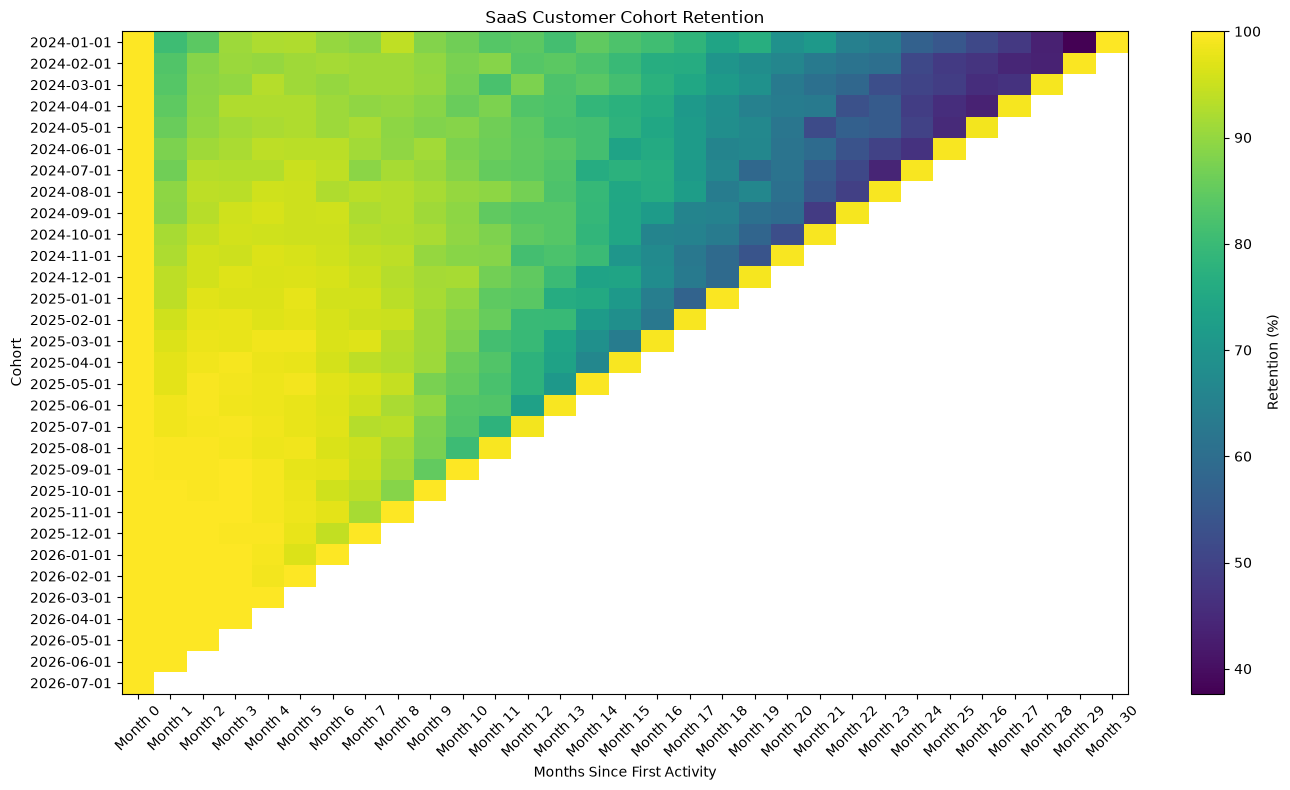

In [13]:
plt.figure(
    figsize=(14, 8)
)

plt.imshow(
    retention_matrix.values,
    aspect="auto",
)

plt.colorbar(
    label="Retention (%)"
)

plt.title(
    "SaaS Customer Cohort Retention"
)

plt.xlabel(
    "Months Since First Activity"
)

plt.ylabel(
    "Cohort"
)

plt.xticks(
    range(len(retention_matrix.columns)),
    retention_matrix.columns,
    rotation=45,
)

plt.yticks(
    range(len(retention_matrix.index)),
    [
        str(x.date())
        for x in retention_matrix.index
    ],
)

plt.tight_layout()

plt.show()

## 12. Average Retention Curve

The cohort matrix shows individual cohort behavior.

The average retention curve provides an overall view of how quickly customer activity declines after acquisition.

In [14]:
retention_curve = (
    cohort_retention
    .groupby("cohort_index")[
        "retention_rate"
    ]
    .mean()
    .reset_index()
)

display(
    retention_curve
)

,cohort_index,retention_rate
0,0,100.00
1,1,94.17
2,2,96.12
3,3,96.57
4,4,96.53
5,5,96.22
6,6,94.92
7,7,93.51
8,8,92.56
9,9,90.30


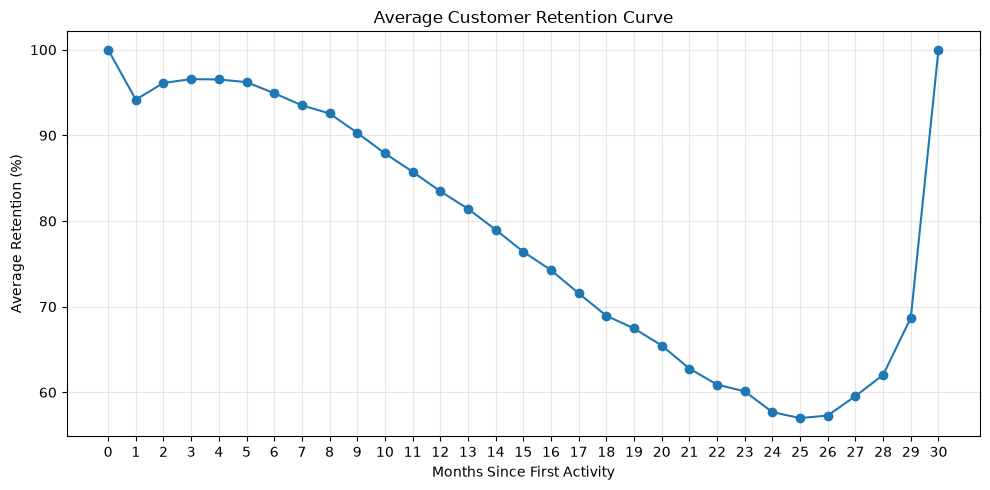

In [15]:
plt.figure(
    figsize=(10, 5)
)

plt.plot(
    retention_curve["cohort_index"],
    retention_curve["retention_rate"],
    marker="o",
)

plt.title(
    "Average Customer Retention Curve"
)

plt.xlabel(
    "Months Since First Activity"
)

plt.ylabel(
    "Average Retention (%)"
)

plt.xticks(
    retention_curve["cohort_index"]
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

## 13. New vs Returning Active Users

Monthly active users can be separated into:

- New active users — first active during that month
- Returning active users — active previously and active again during the month

This helps determine whether product growth is driven primarily by acquisition or continued engagement.

In [16]:
monthly_user_activity = (
    user_month_activity[
        [
            "user_id",
            "event_month",
            "cohort_month",
        ]
    ]
    .drop_duplicates()
)

monthly_user_activity[
    "user_type"
] = np.where(
    monthly_user_activity[
        "event_month"
    ]
    ==
    monthly_user_activity[
        "cohort_month"
    ],
    "New",
    "Returning",
)

new_returning = (
    monthly_user_activity
    .groupby(
        [
            "event_month",
            "user_type",
        ]
    )["user_id"]
    .nunique()
    .reset_index(
        name="users"
    )
)

display(
    new_returning.head(20)
)

,event_month,user_type,users
0,2024-01-01,New,231
1,2024-02-01,New,735
2,2024-02-01,Returning,186
3,2024-03-01,New,942
4,2024-03-01,Returning,806
5,2024-04-01,New,1022
6,2024-04-01,Returning,1648
7,2024-05-01,New,1075
8,2024-05-01,Returning,2584
9,2024-06-01,New,972


## New vs Returning Chart

In [17]:
new_returning_pivot = (
    new_returning
    .pivot(
        index="event_month",
        columns="user_type",
        values="users",
    )
    .fillna(0)
)

display(
    new_returning_pivot
)

user_type,New,Returning
event_month,,
2024-01-01,231.00,0.00
2024-02-01,735.00,186.00
2024-03-01,942.00,806.00
2024-04-01,"1,022.00","1,648.00"
2024-05-01,"1,075.00","2,584.00"
2024-06-01,972.00,"3,556.00"
2024-07-01,"1,045.00","4,518.00"
2024-08-01,"1,070.00","5,455.00"
2024-09-01,"1,016.00","6,496.00"


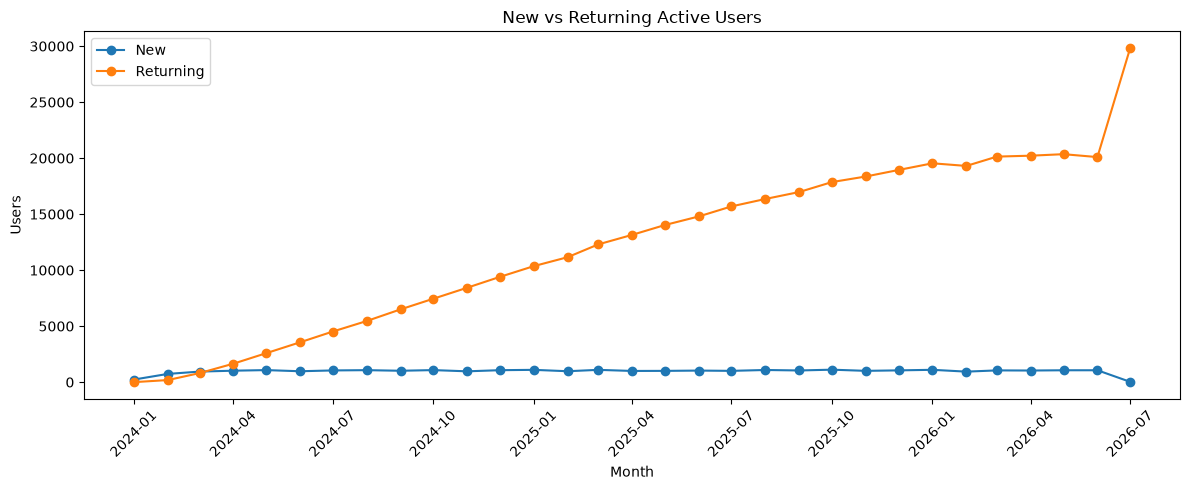

In [18]:
plt.figure(
    figsize=(12, 5)
)

for column in new_returning_pivot.columns:

    plt.plot(
        new_returning_pivot.index,
        new_returning_pivot[column],
        marker="o",
        label=column,
    )

plt.title(
    "New vs Returning Active Users"
)

plt.xlabel(
    "Month"
)

plt.ylabel(
    "Users"
)

plt.legend()

plt.xticks(
    rotation=45
)

plt.tight_layout()

plt.show()

## 14. Retention by Customer Plan

Customer plans may have different retention behavior.

We combine user plan information with activity cohorts to compare retention across customer segments.

In [19]:
if "plan" in users.columns:

    user_plan = (
        users[
            [
                "user_id",
                "plan",
            ]
        ]
        .drop_duplicates(
            "user_id"
        )
    )

    plan_activity = (
        user_month_activity
        .merge(
            user_plan,
            on="user_id",
            how="left",
        )
    )

    plan_cohort = (
        plan_activity
        .groupby(
            [
                "plan",
                "cohort_index",
            ]
        )["user_id"]
        .nunique()
        .reset_index(
            name="active_users"
        )
    )

    plan_cohort_size = (
        plan_activity[
            [
                "user_id",
                "plan",
            ]
        ]
        .drop_duplicates()
        .groupby("plan")
        .size()
        .reset_index(
            name="plan_users"
        )
    )

    plan_cohort = (
        plan_cohort
        .merge(
            plan_cohort_size,
            on="plan",
            how="left",
        )
    )

    plan_cohort[
        "retention_rate"
    ] = (
        plan_cohort["active_users"]
        / plan_cohort["plan_users"]
        * 100
    )

    display(
        plan_cohort
        .head(30)
    )

else:

    plan_cohort = pd.DataFrame()

    print(
        "Plan column not available."
    )

,plan,cohort_index,active_users,plan_users,retention_rate
0,Enterprise,0,2420,2420,100.00
1,Enterprise,1,2362,2420,97.60
2,Enterprise,2,2303,2420,95.17
3,Enterprise,3,2239,2420,92.52
4,Enterprise,4,2157,2420,89.13
5,Enterprise,5,2072,2420,85.62
6,Enterprise,6,1994,2420,82.40
7,Enterprise,7,1904,2420,78.68
8,Enterprise,8,1808,2420,74.71
9,Enterprise,9,1691,2420,69.88


## Retention by Plan Chart

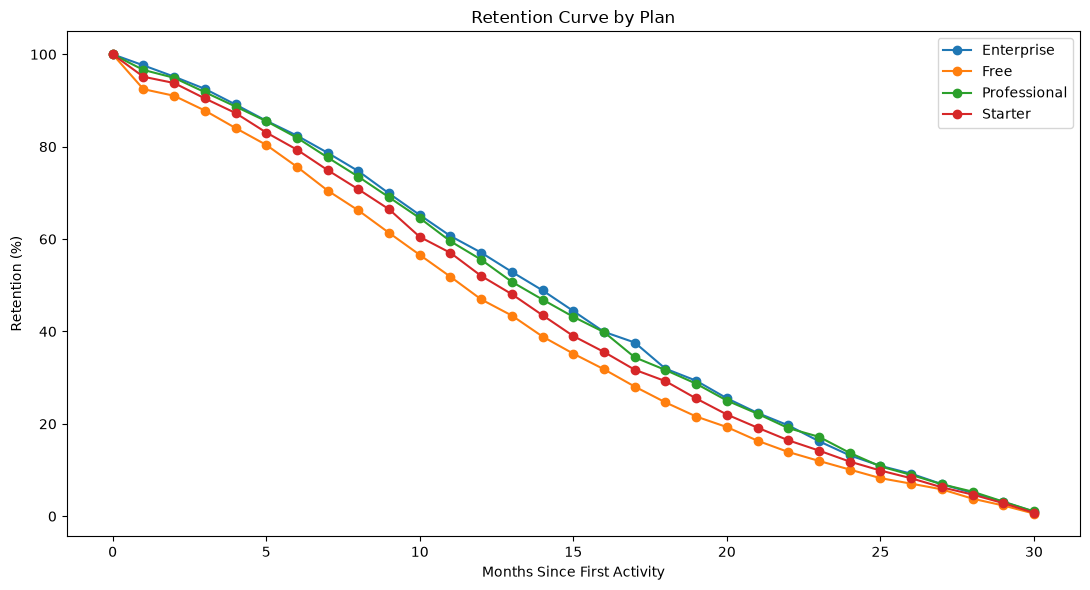

In [20]:
if not plan_cohort.empty:

    plt.figure(
        figsize=(11, 6)
    )

    for plan in plan_cohort[
        "plan"
    ].dropna().unique():

        data = plan_cohort[
            plan_cohort["plan"] == plan
        ]

        plt.plot(
            data["cohort_index"],
            data["retention_rate"],
            marker="o",
            label=str(plan),
        )

    plt.title(
        "Retention Curve by Plan"
    )

    plt.xlabel(
        "Months Since First Activity"
    )

    plt.ylabel(
        "Retention (%)"
    )

    plt.legend()

    plt.tight_layout()

    plt.show()

## 15. Long-Term Retention

A SaaS business should not only evaluate early retention.

We also examine longer-term retention where enough historical data is available.

Important checkpoints include:

- Month 1
- Month 3
- Month 6
- Month 12

In [21]:
retention_checkpoints = [
    1,
    3,
    6,
    12,
]

checkpoint_rows = []

for month in retention_checkpoints:

    checkpoint_data = cohort_retention[
        cohort_retention[
            "cohort_index"
        ] == month
    ]

    if not checkpoint_data.empty:

        checkpoint_rows.append(
            {
                "month": month,
                "average_retention_pct":
                    checkpoint_data[
                        "retention_rate"
                    ].mean(),
                "cohorts_available":
                    len(checkpoint_data),
            }
        )

retention_checkpoints_df = pd.DataFrame(
    checkpoint_rows
)

display(
    retention_checkpoints_df
)

,month,average_retention_pct,cohorts_available
0,1,94.17,30
1,3,96.57,28
2,6,94.92,25
3,12,83.47,19


## 16. User Activity Persistence

Retention can also be examined at the individual customer level.

We calculate:

- Number of active months
- First active month
- Last active month
- Activity lifespan

This helps identify highly persistent customers versus short-lived users.

In [22]:
user_persistence = (
    user_month_activity
    .groupby("user_id")
    .agg(
        first_active_month=(
            "event_month",
            "min",
        ),
        last_active_month=(
            "event_month",
            "max",
        ),
        active_months=(
            "event_month",
            "nunique",
        ),
    )
    .reset_index()
)

user_persistence[
    "activity_span_days"
] = (
    user_persistence[
        "last_active_month"
    ]
    -
    user_persistence[
        "first_active_month"
    ]
).dt.days

display(
    user_persistence.head()
)

,user_id,first_active_month,last_active_month,active_months,activity_span_days
0,U000001,2024-09-01,2026-07-01,18,668
1,U000002,2024-03-01,2026-07-01,18,852
2,U000003,2025-11-01,2026-07-01,9,242
3,U000004,2024-09-01,2026-07-01,17,668
4,U000005,2025-09-01,2026-07-01,11,303


## Persistence Distribution

In [23]:
persistence_summary = (
    user_persistence[
        [
            "active_months",
            "activity_span_days",
        ]
    ]
    .describe()
    .T
)

display(
    persistence_summary
)

,count,mean,std,min,25%,50%,75%,max
active_months,"30,000.00",13.67,6.41,1.00,8.00,14.00,19.00,29.00
activity_span_days,"30,000.00",451.98,254.00,0.00,242.00,456.00,668.00,912.00


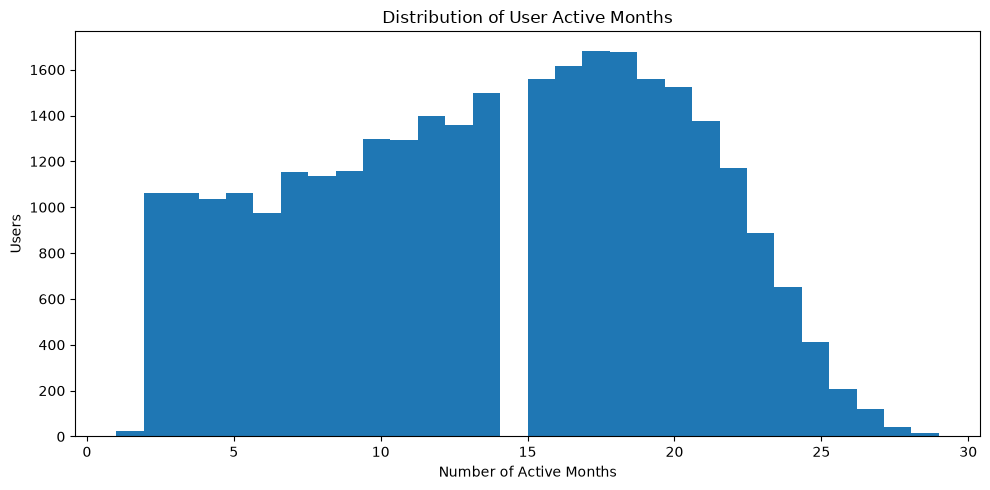

In [24]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    user_persistence[
        "active_months"
    ],
    bins=30,
)

plt.title(
    "Distribution of User Active Months"
)

plt.xlabel(
    "Number of Active Months"
)

plt.ylabel(
    "Users"
)

plt.tight_layout()

plt.show()

## 17. Early Retention Risk Indicator

This is an exploratory behavioral indicator, not a machine-learning prediction.

Users with very limited product activity may represent customers with weaker product adoption.

We identify users with:

- One active month
- Two or fewer active months
- Long-term activity

In [25]:
user_persistence[
    "retention_behavior"
] = pd.cut(
    user_persistence[
        "active_months"
    ],
    bins=[
        -np.inf,
        1,
        2,
        5,
        np.inf,
    ],
    labels=[
        "Single-Month",
        "Low Retention",
        "Moderate Retention",
        "High Retention",
    ],
)

retention_behavior_summary = (
    user_persistence[
        "retention_behavior"
    ]
    .value_counts()
    .rename_axis(
        "retention_behavior"
    )
    .reset_index(
        name="users"
    )
)

retention_behavior_summary[
    "percentage"
] = (
    retention_behavior_summary[
        "users"
    ]
    / len(user_persistence)
    * 100
)

display(
    retention_behavior_summary
)

,retention_behavior,users,percentage
0,High Retention,25755,85.85
1,Moderate Retention,3158,10.53
2,Low Retention,1061,3.54
3,Single-Month,26,0.09


## 18. Save Retention Analytics

The most important analytical outputs are saved to `data/analytics/`.

These files can later be consumed by:

- Streamlit
- Reports
- Dashboards
- Documentation

In [26]:
ANALYTICS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

retention_matrix.to_csv(
    ANALYTICS_DIR
    / "cohort_retention_matrix.csv"
)

cohort_retention.to_csv(
    ANALYTICS_DIR
    / "cohort_retention_long.csv",
    index=False,
)

retention_curve.to_csv(
    ANALYTICS_DIR
    / "retention_curve.csv",
    index=False,
)

new_returning.to_csv(
    ANALYTICS_DIR
    / "new_vs_returning_users.csv",
    index=False,
)

user_persistence.to_csv(
    ANALYTICS_DIR
    / "user_persistence.csv",
    index=False,
)

print(
    "Retention analytics saved successfully."
)

Retention analytics saved successfully.


## 19. Connection to `business_questions.md`

Retention analysis contributes to the existing master business-question framework.

The analysis provides evidence for questions concerning:

- Customer retention
- Customer churn
- Cohort performance
- Product engagement
- Returning customers
- Customer lifecycle
- Plan-level customer behavior
- Long-term customer activity

The existing `business_questions.md` remains the authoritative source for the project's business questions.

This notebook does not replace or redefine those questions.

Instead, it provides analytical evidence that will eventually be consolidated into `insight.md`.

## Key Findings

In [27]:
print("RETENTION ANALYSIS SUMMARY")
print("=" * 60)

print(
    f"Users with product activity: "
    f"{len(first_activity):,}"
)

print(
    f"Cohorts analyzed: "
    f"{first_activity['cohort_month'].nunique():,}"
)

if not retention_checkpoints_df.empty:

    for _, row in retention_checkpoints_df.iterrows():

        print(
            f"Month {int(row['month'])} "
            f"average retention: "
            f"{row['average_retention_pct']:.2f}%"
        )

print(
    "\nAverage active months per user:",
    f"{user_persistence['active_months'].mean():.2f}"
)

print(
    "Median active months per user:",
    f"{user_persistence['active_months'].median():.0f}"
)

RETENTION ANALYSIS SUMMARY
Users with product activity: 30,000
Cohorts analyzed: 31
Month 1 average retention: 94.17%
Month 3 average retention: 96.57%
Month 6 average retention: 94.92%
Month 12 average retention: 83.47%

Average active months per user: 13.67
Median active months per user: 14


## 20. Retention Analysis — Business Interpretation

### Cohort Performance

Cohort analysis allows the business to compare customers based on when they first became active.

### Early Retention

Month 1 retention is an important indicator of whether users successfully transition from initial adoption into recurring product usage.

### Long-Term Retention

Month 3, Month 6, and Month 12 retention provide progressively stronger evidence of customer stickiness.

### New vs Returning Users

A healthy SaaS product should develop a strong base of returning users rather than relying entirely on new customer acquisition.

### Customer Persistence

The number of active months provides a customer-level view of product stickiness.

### Plan Differences

Different subscription plans may demonstrate different retention patterns and therefore require different customer-success strategies.

### Churn Connection

Customers with declining or limited product activity may represent potential churn-risk populations.

These behavioral patterns will become important inputs for the dedicated churn analysis and machine-learning stages.

## 21. Conclusion

The retention and cohort analysis establishes how customer engagement persists over time.

The analysis covered:

- User cohorts
- Monthly retention
- Cohort retention matrix
- Retention curves
- New vs returning users
- Plan-level retention
- Long-term retention
- User activity persistence
- Exploratory retention-risk indicators

The analysis provides the bridge between product usage and customer churn.

The next stage will examine the financial side of the SaaS business.

---

**Next Notebook:** `05_Revenue_Analytics.ipynb`